# 自定义中间件

通过实现运行在Agent执行流程中特定的hooks来构建自定义中间件

## Hooks 钩子
中间件提供两种风格来拦截Agent的执行流程：
1. Node-style：节点风格，在特定的节点上执行
2. Wrap-style：包裹风格，围绕每一个agent或者model调用



### Node-style 节点风格
在特定的执行点按照顺序执行。用于记录日志、验证和状态更新

有4种可用的hooks：
1. before_model：在模型调用之前执行
2. after_model：在模型调用之后执行
3. before_agent：在agent调用之前执行（只执行一次）
4. after_agent：在agent完成时执行（只执行一次）


In [ ]:
import os

from langchain_openai import ChatOpenAI

model = ChatOpenAI(
    model="deepseek-ai/DeepSeek-V3",
    #! 这里要注意，模型的Tools能力也挂钩
    base_url="https://api.siliconflow.cn/v1",
    api_key=os.environ.get("SILICONFLOW_API_KEY"),
    temperature=0.2,
)

In [ ]:
from typing import Any

from langchain.agents import AgentState, create_agent
from langchain.agents.middleware import (
    after_agent,
    after_model,
    before_agent,
    before_model,
)
from langchain.messages import AIMessage, HumanMessage
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.runtime import Runtime

# 在进入model之前检查信息的限制


@before_model(can_jump_to=["end"])
def check_message_limit(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """检查消息是否超过限制"""

    # ? state 和 runtime 都是 AgentState 的实例
    # ? state 包含了当前的状态，比如消息历史、工具调用等
    # ? runtime 包含了运行时的信息，比如环境变量、配置等
    # 这两个都会自动的注入，可以在中间件中访问
    if len(state["messages"]) >= 2:  # 一轮对话
        # 返回一个消息
        return {
            "messages": [AIMessage(content="您的消息超过了限制，请减少消息数量")],
            "jump_to": "end",
        }
    # 没事发生，返回None
    return None


# 输出agent的log
@before_model
def log_agent(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """输出agent的log"""
    print("666")
    return None


agent = create_agent(
    model,
    tools=[],
    middleware=[check_message_limit, log_agent],
    checkpointer=InMemorySaver(),
)

config = {"configurable": {"thread_id": "user_1"}}

agent.invoke({"messages": [HumanMessage(content="你好")]}, config=config)["messages"][
    -1
].pretty_print()
agent.invoke({"messages": [HumanMessage(content="我是一个自私的人")]}, config=config)[
    "messages"
][-1].pretty_print()
agent.invoke({"messages": [HumanMessage(content="我真是废物")]}, config=config)[
    "messages"
][-1].pretty_print()


666
================================== Ai Message ==================================

你好！😊 很高兴见到你～有什么我可以帮你的吗？
================================== Ai Message ==================================

您的消息超过了限制，请减少消息数量
================================== Ai Message ==================================

您的消息超过了限制，请减少消息数量


### Wrap-style 包裹节点风格

当handler被调用时拦截执行并且控制其行为，用于缓存、重试和转换

可以自定义handler 调用零次（短路）、一次（正常）或者多次（重试）

可用的hooks：
- wrap_model_call: 每一个model调用期间
- wrap_tool_call: 每一个tool调用期间

In [ ]:
from typing import Callable

from langchain.agents.middleware import ModelRequest, ModelResponse, wrap_model_call


# 使用装饰器来实现
@wrap_model_call(name="retry_model_call")
def retry_model_call(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse],
) -> ModelResponse:
    """重试model调用"""
    for attempt in range(3):
        try:
            # ? 这个就是向流程后面的handler传递request
            # 也就是继续执行的意思
            # 这里如果失败了就会抛出异常
            return handler(request)
        except Exception as e:
            if attempt == 2:
                raise e
            print(f"Retry {attempt + 1}/3 after error: {e}")

In [ ]:
# 使用class来实现

from typing import Callable

from langchain.agents.middleware import AgentMiddleware, ModelRequest, ModelResponse


class RetryMiddleware(AgentMiddleware):
    def __init__(self, max_retries: int = 3):
        super().__init__()  # 调用父类的构造方法
        self.max_retries = max_retries  # 定义类属性

    def wrap_model_call(
        self,
        request: ModelRequest,
        handler: Callable[[ModelRequest], ModelResponse],
        # ? handler: 这是一个函数，用于处理model调用
        # ? 它接受一个ModelRequest对象作为参数，返回一个ModelResponse对象
    ) -> ModelResponse:
        for attempt in range(self.max_retries):
            try:
                return handler(request)
            except Exception as e:
                if attempt == self.max_retries - 1:
                    raise
                print(f"Retry {attempt + 1}/{self.max_retries} after error: {e}")

## State update 更新状态

节点式钩子和包裹式钩子都可以去更新agent的State，但是机制有所不同

节点式钩子（ before_agent ， before_model ， after_model ， after_agent ）： 

**直接返回一个字典** ，这个字典也就是一个符合schema的字典

> 该字典使用图中的 reducer 应用于代理状态。

包装式钩子（ wrap_model_call ， wrap_tool_call ）：

对于模型调用，返回 **ExtendedModelResponse** 并附带 **Command** 以在模型响应中注入状态更新

对于工具调用，直接返回 **Command** 。当你需要根据模型或工具调用期间运行的逻辑来跟踪或更新状态时使用这些钩子，例如摘要触发点、使用元数据或从请求或响应计算的自定义字段

In [ ]:
from typing import Any

from langchain.agents.middleware import AgentState
from langgraph.runtime import Runtime
from typing_extensions import NotRequired


class TrackingState(AgentState):
    # ? 继承AgentState来扩展状态字段
    model_call_count: NotRequired[int]  # 可选字段


@after_model(state_schema=TrackingState)
def increment_after_model(
    state: TrackingState, runtime: Runtime
) -> dict[str, Any] | None:
    return {"model_call_count": state.get("model_call_count", 0) + 1}


包裹风格的hooks，返回一个 **ExtendedModelResponse** 里边包括Command ，来注入模型的调用层的状态更新

In [ ]:
from typing import Callable

from langchain.agents.middleware import (
    AgentState,
    ExtendedModelResponse,  # 扩展模型响应
    ModelRequest,
    ModelResponse,
    wrap_model_call,
)
from langgraph.types import Command  # 命令类型
from typing_extensions import NotRequired  # 可选字段


class UsageTrackingState(AgentState):
    """Agent state with token usage tracking."""

    last_model_call_tokens: NotRequired[int] = Field(
        default=None,
        description="Number of tokens used in the last model call.",
    )


def track_usage(
    request: ModelRequest, handler: Callable[[ModelRequest], ModelResponse]
) -> ExtendedModelResponse:
    response = handler(request)  # 向后传递，拿到模型的响应
    return ExtendedModelResponse(
        model_response=response,
        command=Command(update={"last_model_call_tokens": 150}),
    )

Command 流经图中的 **reducer** ，因此更新可以正确应用，消息是累积的而不是替换现有状态。

#### Reducer 约束器 -- 管理多个中间件更新的结果

Reducer 的两种主要类型

Reducer 是LangGraph中控制状态更新如何应用的机制。当中间件或节点返回状态更新时，这些更新通过Reducer函数合并到现有状态中。

1. Additive Reducer（累加型）

**用途**：消息字段（messages）等需要累积的场景

**行为**：多个更新会累积，新的值会追加到现有值之后，而不是覆盖

**实现方式**：使用 `operator.add` 或 LangGraph 内置的 `add_messages`

```python
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]  # 累加消息
    items: Annotated[list[str], operator.add]           # 累加列表
```

**示例**：内层中间件添加 `"[Inner ran]"`，外层添加 `"[Outer ran]"`，最终两条消息都会保留在状态中。

---

2. Last-wins Reducer（覆盖型）

**用途**：计数器、标志位、trace_layer等只需要最终值的场景

**行为**：后写入的值直接覆盖先写入的值

**实现方式**：自定义函数，只返回新值；或显式使用 `Overwrite` 类型

```python
def _last_wins(_a: str, b: str) -> str:
    """Reducer：后写入的值获胜"""
    return b

class State(TypedDict):
    trace_layer: Annotated[str, _last_wins]  # 最后写入的值覆盖之前的
    model_call_count: int                     # 默认覆盖
```

---

3. 隐式覆盖Reducer（默认行为）

如果状态字段没有指定Reducer，**默认行为是直接覆盖**。这适用于只需要最终值的场景：

```python
class State(TypedDict):
    turn: int              # 无Reducer：每次覆盖
    session_id: str        # 无Reducer：每次覆盖
```

---

 4. Overwrite：绕过Reducer

有时需要**强制覆盖**而非合并。LangGraph提供 `Overwrite` 类型：

```python
from langgraph.types import Overwrite

def replace_messages(state: State):
    # 使用Overwrite绕过reducer，直接替换整个消息列表
    return {"messages": Overwrite(["全新消息"])}
```

---

Reducer在中间件中的应用

当中间件返回状态更新时：

| 中间件类型 | 返回方式 | Reducer处理 |
|-----------|---------|------------|
| Node-style | 直接返回字典 | 通过对应字段的Reducer合并 |
| Wrap-style | `Command(update={...})` | 通过对应字段的Reducer合并 |

**示例**：两个中间件都更新 `trace_layer` 字段

```python
class CustomMiddlewareState(AgentState):
    trace_layer: NotRequired[Annotated[str, _last_wins]]  # 外层覆盖
    messages: NotRequired[Annotated[list, operator.add]]  # 累加

# 内层返回
{"trace_layer": "inner", "messages": [SystemMessage("[Inner ran]")]}

# 外层返回
{"trace_layer": "outer", "messages": [SystemMessage("[Outer ran]")]}

# 结果：trace_layer="outer"（覆盖），messages=[内层消息, 外层消息]（累加）
```

【为什么要reducer约束器？？】

在复杂的中间件架构中，多个中间件层可能独立地更新状态。如果没有 Reducer：状态更新可能会相互覆盖，导致数据丢失，无法预测最终状态值，调试困难，难以追踪哪个中间件影响了最终结果

Reducer 提供了确定性的冲突解决策略，确保无论中间件执行顺序如何，状态更新都有可预测的行为。

In [ ]:
from typing import Annotated, Callable

from langchain.agents.middleware import (
    AgentMiddleware,
    AgentState,
    ExtendedModelResponse,
    ModelRequest,
    ModelResponse,
)
from langchain.messages import SystemMessage
from typing_extensions import NotRequired


def _last_wins(_a: str, b: str) -> str:
    """Reducer: last writer wins (outer overwrites inner)."""
    return b


class CustomMiddlewareState(AgentState):
    """Agent state: trace_layer uses last-wins (outer wins), messages use additive reducer."""

    # Non-reducer field with last-wins: both middleware write; outermost value wins
    trace_layer: NotRequired[Annotated[str, _last_wins]]


class OuterMiddleware(AgentMiddleware):
    def wrap_model_call(
        self,
        request: ModelRequest,
        handler: Callable[[ModelRequest], ModelResponse],
    ) -> ExtendedModelResponse:
        response = handler(request)
        return ExtendedModelResponse(
            model_response=response,
            command=Command(
                update={
                    "trace_layer": "outer",
                    "messages": [SystemMessage(content="[Outer ran]")],
                }
            ),
        )


class InnerMiddleware(AgentMiddleware):
    """Adds trace_layer and message. Outer adds to same keys; trace_layer: outer wins, messages: additive."""

    def wrap_model_call(
        self,
        request: ModelRequest,
        handler: Callable[[ModelRequest], ModelResponse],
    ):
        response = handler(request)
        return ExtendedModelResponse(
            model_response=response,
            command=Command(
                update={
                    "trace_layer": "inner",
                    "messages": [SystemMessage(content="[Inner ran]")],
                }
            ),
        )


【总结】

| 钩子类型 | 执行时机 | 返回值处理 |
|---------|---------|-----------|
| before_agent | Agent执行前（1次）| 字典 -> Reducer合并 |
| before_model | 每次模型调用前 | 字典 -> Reducer合并 |
| after_model | 每次模型调用后 | 字典 -> Reducer合并 |
| after_agent | Agent完成后（1次）| 字典 -> Reducer合并 |
| wrap_model_call | 环绕模型调用 | Command -> Reducer合并 |

关键点：无论哪种钩子，返回的状态更新都会通过对应字段的Reducer进行合并

有两种构建中间件的方式，分别是：
1. 直接装饰器
2. 继承AgentMiddleware类实现

### 构建中间件
#### 使用装饰器
对于单个hooks的中间件，使用装饰器修饰对应的hooks函数即可，快速、方便且简单

这里补充一个 @dynamic_prompt 装饰器，用于动态生成系统提示词


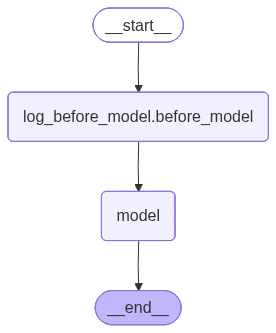

In [ ]:
from typing import Any, Callable

from langchain.agents import create_agent
from langchain.agents.middleware import (
    AgentState,
    ModelRequest,
    ModelResponse,
    before_model,
    wrap_model_call,
)
from langgraph.runtime import Runtime


@before_model
def log_before_model(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    print(f"About to call model with {len(state['messages'])} messages")
    return None


@wrap_model_call
def retry_model(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse],
) -> ModelResponse:
    for attempt in range(3):
        try:
            return handler(request)
        except Exception as e:
            if attempt == 2:
                raise
            print(f"Retry {attempt + 1}/3 after error: {e}")


agent = create_agent(
    model=model,
    middleware=[log_before_model, retry_model],
)

agent

当一个中间件只有一个hooks函数的时候，无需复杂的逻辑和配置，并且可以快速开发，这种情况可以直接使用装饰器修饰对应的hooks函数


####  继承AgentMiddleware类实现
对于具有多个hooks函数和配置的复杂中间件，当你需要为同一个钩子定义同步和异步实现，或者当你希望将多个钩子组合在单个中间件中时，请使用类。

多个hooks函数在类的内部可以交换数据，更加灵活和方便，不用在全局定义变量

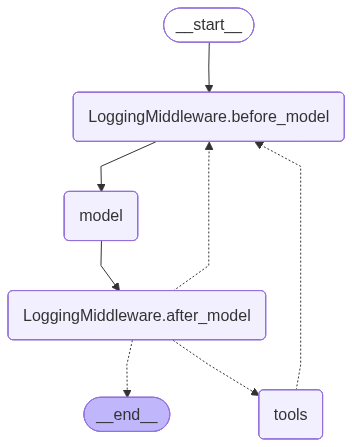

In [ ]:
from typing import Any, Callable

from langchain.agents.middleware import (
    AgentMiddleware,
    AgentState,
    ModelRequest,
    ModelResponse,
)

# 定义一个工具
from langchain.tools import tool
from langgraph.runtime import Runtime


@tool
def get_current_time() -> str:
    """Get the current time in the format HH:MM:SS"""
    import datetime

    return datetime.datetime.now().strftime("%H:%M:%S")


class LoggingMiddleware(AgentMiddleware):
    def before_model(
        self, state: AgentState, runtime: Runtime
    ) -> dict[str, Any] | None:
        print(f"About to call model with {len(state['messages'])} messages")
        return None

    def after_model(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        print(f"Model returned: {state['messages'][-1].content}")
        return None


agent = create_agent(
    model,
    middleware=[LoggingMiddleware()],
    tools=[get_current_time],
)

agent

【什么是用类实现自定义中间件？】

- 需要实现同一个钩子函数的同步和异步版本
- 单个中间件中需要多个钩子函数
- 需要复杂的配置，比如说，阈值、自定义模型
- 跨项目可复用，通过初始化时配置，直接导入类就能用了


### 自定义State的Schema
中间件可以扩展agent的State，添加新的字段，或者修改已有的字段。

中间件可以：
- 跟踪执行过程中的State，比如说维护在整个agent执行生命周期中持续存在的计数器、标志或者其他变量
- 在钩子之间共享数据，将信息从before_hook传递到after_hook，或者在不同中间件实例之间传递
- 实现横切关注点：无需修改核心代码的逻辑，即可添加限流、使用跟踪、用户上下文或审计日志等功能
- 进行条件性决策：使用累积状态来确定是否继续执行、跳转到不同的节点或动态修改行为

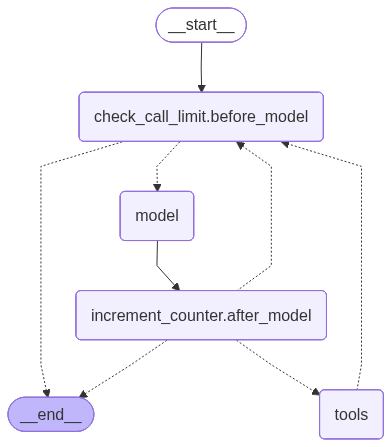

In [ ]:
from typing import Any

from langchain.agents import create_agent
from langchain.agents.middleware import AgentState, after_model, before_model
from langchain.messages import HumanMessage
from langgraph.runtime import Runtime  # 图运行时
from typing_extensions import NotRequired


class CustomState(AgentState):
    model_call_cnt: NotRequired[int] = 0
    user_id: NotRequired[str] = ""


# ? can_jump_to 是一个列表，用于指定在中间件中可以跳转的状态，包含 end, tool, model 三种
@before_model(state_schema=CustomState, can_jump_to=["end"])
def check_call_limit(state: CustomState, runtime: Runtime) -> dict[str, Any] | None:
    cnt = state.get("model_call_cnt", 0)
    if cnt >= 10:
        return {"jump_to": "end"}
    return None


@after_model(state_schema=CustomState)
def increment_counter(state: CustomState, runtime: Runtime) -> dict[str, Any] | None:
    return {"model_call_count": state.get("model_call_count", 0) + 1}


agent = create_agent(
    model,
    middleware=[check_call_limit, increment_counter],
    tools=[get_current_time],
)

agent

In [ ]:
# Invoke with custom state
result = agent.invoke(
    {
        "messages": [HumanMessage("Hello")],
        "model_call_count": 0,
        "user_id": "user-123",
    }
)["messages"][-1].pretty_print()


================================== Ai Message ==================================

Hello! How can I assist you today?


input: _InputAgentState | Command | None

invoke第一个参数传入的是 _InputAgentState 类型的字典，包含了模型调用的输入信息，例如 messages, model_call_count, user_id 等，还可以传入Command类型的对象

### 中间件执行顺序

- before 钩子按照传入给agent的列表的 **顺序** 执行
- wrap 钩子会像函数嵌套一样，从外到内包裹
- after 钩子按照传入给agent的列表 **逆序** 执行

关键规则：
- before 是按照顺序执行的
- wrap 是按照顺序包裹的
- after 是按照逆序执行的



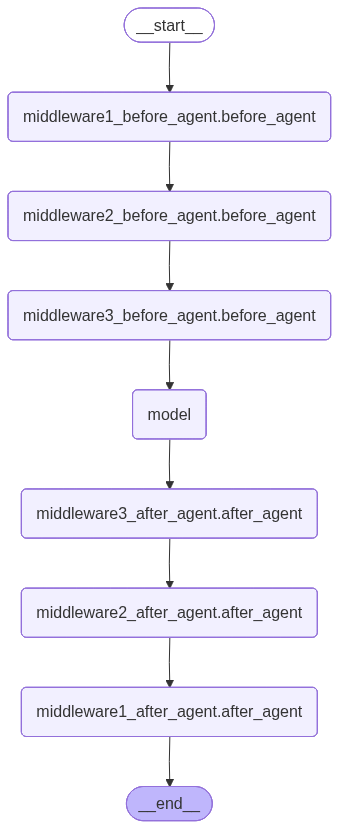

In [ ]:
from typing import Any, Callable

from langchain.agents import create_agent
from langchain.agents.middleware import (
    AgentMiddleware,
    AgentState,
    ModelRequest,
    ModelResponse,
    wrap_model_call,
)
from langchain.messages import HumanMessage
from langgraph.runtime import Runtime

# ===== 装饰器风格中间件 =====


@before_agent
def middleware1_before_agent(
    state: AgentState, runtime: Runtime
) -> dict[str, Any] | None:
    print(">>> middleware1: before_agent")
    return None


@after_agent
def middleware1_after_agent(
    state: AgentState, runtime: Runtime
) -> dict[str, Any] | None:
    print(">>> middleware1: after_agent")
    return None


@wrap_model_call
def middleware1_wrap(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse],
) -> ModelResponse:
    print(">>> middleware1: wrap_model_call [进入]")
    result = handler(request)
    print(">>> middleware1: wrap_model_call [退出]")
    return result


@before_agent
def middleware2_before_agent(
    state: AgentState, runtime: Runtime
) -> dict[str, Any] | None:
    print(">>> middleware2: before_agent")
    return None


@after_agent
def middleware2_after_agent(
    state: AgentState, runtime: Runtime
) -> dict[str, Any] | None:
    print(">>> middleware2: after_agent")
    return None


@wrap_model_call
def middleware2_wrap(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse],
) -> ModelResponse:
    print(">>> middleware2: wrap_model_call [进入]")
    result = handler(request)
    print(">>> middleware2: wrap_model_call [退出]")
    return result


@before_agent
def middleware3_before_agent(
    state: AgentState, runtime: Runtime
) -> dict[str, Any] | None:
    print(">>> middleware3: before_agent")
    return None


@after_agent
def middleware3_after_agent(
    state: AgentState, runtime: Runtime
) -> dict[str, Any] | None:
    print(">>> middleware3: after_agent")
    return None


@wrap_model_call
def middleware3_wrap(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse],
) -> ModelResponse:
    print(">>> middleware3: wrap_model_call [进入]")
    result = handler(request)
    print(">>> middleware3: wrap_model_call [退出]")
    return result


# ===== 创建 Agent =====
agent = create_agent(
    model,
    middleware=[
        middleware1_before_agent,
        middleware1_wrap,
        middleware1_after_agent,
        middleware2_before_agent,
        middleware2_wrap,
        middleware2_after_agent,
        middleware3_before_agent,
        middleware3_wrap,
        middleware3_after_agent,
    ],
    tools=[],
)

agent

In [ ]:
# ===== 运行 =====
print("\n" + "=" * 50)
print("开始执行 Agent")
print("=" * 50 + "\n")

result = agent.invoke(
    {
        "messages": [HumanMessage("你好，介绍一下你自己")],
    }
)

print("\n" + "=" * 50)
print("执行完成")
print("=" * 50)



开始执行 Agent

>>> middleware1: before_agent
>>> middleware2: before_agent
>>> middleware3: before_agent
>>> middleware1: wrap_model_call [进入]
>>> middleware2: wrap_model_call [进入]
>>> middleware3: wrap_model_call [进入]
>>> middleware3: wrap_model_call [退出]
>>> middleware2: wrap_model_call [退出]
>>> middleware1: wrap_model_call [退出]
>>> middleware3: after_agent
>>> middleware2: after_agent
>>> middleware1: after_agent

执行完成


## 钩子函数签名对比

| 风格 | 钩子 | 函数签名 | 返回值 |
|------|------|---------|--------|
| **Node** | `before_agent`, `after_agent`, `before_model`, `after_model` | `(state: AgentState, runtime: Runtime)` | `dict \| None` |
| **Wrap** | `wrap_model_call`, `wrap_tool_call` | `(request: ModelRequest, handler: Callable)` | `ModelResponse` |

**Node 风格**：适合顺序逻辑（日志、验证、状态更新），直接返回字典

**Wrap 风格**：适合控制流（重试、缓存、短路），通过 `handler(request)` 决定调用次数


### agent 跳转
agent jumps

要从中间件中提前退出，返回包含 "jump_to" 键的字典

可以跳转的目标：
- 'end' ：跳转到agent执行流程的末尾，或者第一个after_agent的钩子
- 'tools' ：跳转到工具节点，不能具体控制跳转到哪一个Tool，这个是让agent自己决定用哪个Tool
- 'model' ： 跳转到模型节点，或者第一个before_model的钩子



In [ ]:
from typing import Any

from langchain.agents.middleware import AgentState, after_model, hook_config
from langgraph.runtime import Runtime


@after_model
@hook_config(can_jump_to=["end"])  # hook_config也可以直接定义在after_model装饰器中
def check_for_blocked(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    last_message = state["messages"][-1]
    if "BLOCKED" in last_message.content:
        return {
            "messages": [AIMessage("I cannot respond to that request.")],
            "jump_to": "end",
        }
    return None


## 最佳实践
1. 保持中间件专注，每一个中间件只做好一件事情
2. 优雅的处理错误，不要让中间件错误导致agent崩溃
3. 适当选择钩子类型
   1. node风格适合顺序逻辑，日志记录、验证等
   2. wrap风格适合控制流，重试、回退、缓存
4. 清晰记录任何自定义State属性
5. 独立测试中间件，然后再集成
6. 考虑执行顺序，将关键的中间件放在列表的前面
7. 尽可能使用内置的中间件



### 使用中间件动态配置Tools

- 更短的提示，通过仅暴露相关的工具来降低选择的复杂性
- 更高的准确性，更少的选择带来更高的准确性
- 权限控制，基于用户访问状态来筛选工具

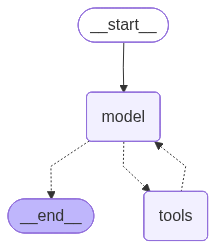

In [ ]:
from typing import Callable

from langchain.agents import create_agent
from langchain.agents.middleware import ModelRequest, ModelResponse, wrap_model_call


@wrap_model_call
def select_tools(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse],
) -> ModelResponse:
    """Middleware to select relevant tools based on state/context."""
    # Select a small, relevant subset of tools based on state/context
    # 这里没有实现对应的逻辑select_relevant_tools
    relevant_tools = select_relevant_tools(request.state, request.runtime)
    return handler(request.override(tools=relevant_tools))


all_tools = [get_current_time]

agent = create_agent(
    model,
    tools=all_tools,  # All available tools need to be registered upfront
    middleware=[select_tools],
)

agent